Parse results

In [8]:
# Import required modules
import sys
from pathlib import Path
import json
import re
from bs4 import BeautifulSoup

# Path to your idf_output directory from notebook 02
idf_output_path = Path.cwd() / "idf_output"

print(f"Searching for results in: {idf_output_path}")
print(f"Directory exists: {idf_output_path.exists()}")

# Standalone parsing functions (no Django dependency)
def parse_readvars_csv(csv_path):
    """Parse EnergyPlus CSV output into timeseries data."""
    csv_path = Path(csv_path)
    series = {}
    
    try:
        import csv
        with open(csv_path, 'r', encoding='utf-8') as f:
            reader = csv.reader(f)
            rows = list(reader)
            
        if len(rows) < 2:
            return {'is_hourly': False, 'rows': 0, 'series': {}}
        
        # Find header row (starts with empty cell followed by variable names)
        header_idx = 0
        for i, row in enumerate(rows[:10]):
            if len(row) > 1 and row[0].strip() == '':
                header_idx = i
                break
        
        headers = rows[header_idx]
        data_rows = rows[header_idx + 1:]
        
        # Parse numeric columns only
        for col_idx, header in enumerate(headers[1:], 1):  # Skip first column (date/time)
            var_name = re.sub(r'\(.*?\)', '', header).strip()
            var_name = re.sub(r'[^0-9A-Za-z_]+', '_', var_name).strip('_')
            
            values = []
            for row in data_rows[:20000]:  # Limit rows
                if col_idx < len(row):
                    try:
                        values.append(float(row[col_idx]))
                    except:
                        pass
            
            if values:
                series[var_name] = values
        
        return {
            'is_hourly': len(data_rows) >= 8000,
            'rows': len(data_rows),
            'series': series
        }
    except Exception as e:
        print(f"Error parsing CSV: {e}")
        return {'is_hourly': False, 'rows': 0, 'series': {}}


def parse_html_results(html_path, building_name):
    """Parse EnergyPlus HTML output for key metrics - handles both HVAC and district systems."""
    try:
        with open(html_path, 'r', encoding='utf-8') as f:
            soup = BeautifulSoup(f, 'html.parser')
        
        def get_value_from_table(table_title, row_label, col_index=1):
            """Locate a table by title and return value at row_label and column index."""
            table_header = soup.find('b', string=table_title)
            if not table_header:
                return None
            table = table_header.find_next('table')
            if not table:
                return None
            for row in table.find_all('tr'):
                cells = row.find_all(['td', 'th'])
                if cells and cells[0].get_text(strip=True) == row_label:
                    if col_index < len(cells):
                        try:
                            value_text = cells[col_index].get_text(strip=True)
                            return float(re.sub(r'[^\d.eE+-]', '', value_text))
                        except:
                            return None
            return None
        
        # Extract values using the same approach as services.py
        total_energy_use = get_value_from_table("Site and Source Energy", "Total Site Energy", 2)  # kWh/m²
        total_area = get_value_from_table("Building Area", "Total Building Area", 1)  # m²
        
        # Extract from End Uses table (column 12 has annual kWh)
        heating_kwh = get_value_from_table("End Uses", "Heating", 12) or 0.0
        cooling_kwh = get_value_from_table("End Uses", "Cooling", 12) or 0.0
        lighting_kwh = get_value_from_table("End Uses", "Interior Lighting", 1) or 0.0
        equipment_kwh = get_value_from_table("End Uses", "Interior Equipment", 1) or 0.0
        
        # Also check for district heating/cooling (in kWh/m² from Site and Source Energy table)
        district_cooling = get_value_from_table("Site and Source Energy", "District Cooling", 2) or 0.0
        district_heating_water = get_value_from_table("Site and Source Energy", "District Heating Water", 2) or 0.0
        district_heating_steam = get_value_from_table("Site and Source Energy", "District Heating Steam", 2) or 0.0
        
        if not total_area or total_area < 1:
            total_area = 1.0  # fallback to avoid division by zero
        
        # If End Uses heating/cooling are from kWh total, normalize by area
        # Otherwise if they're already intensity (kWh/m²), use directly
        heating_from_enduses = heating_kwh / total_area if heating_kwh and heating_kwh > 100 else heating_kwh
        cooling_from_enduses = cooling_kwh / total_area if cooling_kwh and cooling_kwh > 100 else cooling_kwh
        
        # Combine HVAC and district systems
        heating_demand = heating_from_enduses + district_heating_water + district_heating_steam
        cooling_demand = cooling_from_enduses + district_cooling
        lighting_demand = lighting_kwh / total_area if lighting_kwh and lighting_kwh > 100 else lighting_kwh
        equipment_demand = equipment_kwh / total_area if equipment_kwh and equipment_kwh > 100 else equipment_kwh
        
        results = {
            'building': building_name,
            'status': 'Success',
            'totalEnergyUse': round(total_energy_use, 2) if total_energy_use else 0.0,
            'heatingDemand': round(heating_demand, 2),
            'coolingDemand': round(cooling_demand, 2),
            'lightingDemand': round(lighting_demand, 2),
            'equipmentDemand': round(equipment_demand, 2),
            'totalArea': round(total_area, 2) if total_area else 0.0,
            'runTime': 0.0,
            # Add breakdown for transparency
            'districtHeatingWater': round(district_heating_water, 2),
            'districtHeatingSteam': round(district_heating_steam, 2),
            'districtCooling': round(district_cooling, 2)
        }
        
        return results
        
    except Exception as e:
        print(f"Error parsing HTML: {e}")
        import traceback
        traceback.print_exc()
        return {
            'building': building_name,
            'status': 'Failed',
            'error': str(e)
        }


# Parse only city_optimized
if not idf_output_path.exists():
    print("⚠️  idf_output directory not found. Run notebook 02 first.")
else:
    building_name = "city_optimized"
    html_path = idf_output_path / f"{building_name}Table.html"
    csv_path = idf_output_path / f"{building_name}.csv"
    
    if not html_path.exists():
        print(f"❌ HTML file not found: {html_path}")
    else:
        print(f"\n{'='*60}")
        print(f"Processing: {building_name}")
        print(f"{'='*60}")
        
        try:
            # Parse HTML results
            results = parse_html_results(html_path, building_name)
            
            # Parse hourly CSV data if available
            if csv_path.exists():
                try:
                    print(f"  Parsing CSV: {csv_path.name}")
                    hourly_data = parse_readvars_csv(csv_path)
                    if hourly_data and hourly_data.get('is_hourly'):
                        results['hourly_timeseries'] = hourly_data
                        print(f"  ✓ Parsed hourly data: {hourly_data['rows']} timesteps")
                        print(f"  ✓ Available variables: {list(hourly_data['series'].keys())[:5]}...")
                except Exception as e:
                    print(f"  ⚠️  Failed to parse CSV: {e}")
            
            # Display key metrics
            print(f"\n  Building: {results.get('building')}")
            print(f"  Total Energy Use: {results.get('totalEnergyUse', 0):.2f} kWh/m²")
            print(f"  Heating Demand: {results.get('heatingDemand', 0):.2f} kWh/m²")
            print(f"    - District Heating Water: {results.get('districtHeatingWater', 0):.2f} kWh/m²")
            print(f"    - District Heating Steam: {results.get('districtHeatingSteam', 0):.2f} kWh/m²")
            print(f"  Cooling Demand: {results.get('coolingDemand', 0):.2f} kWh/m²")
            print(f"    - District Cooling: {results.get('districtCooling', 0):.2f} kWh/m²")
            print(f"  Lighting: {results.get('lightingDemand', 0):.2f} kWh/m²")
            print(f"  Equipment: {results.get('equipmentDemand', 0):.2f} kWh/m²")
            print(f"  Total Area: {results.get('totalArea', 0):,.2f} m²")
            print(f"  Run Time: {results.get('runTime', 0):.2f} seconds")
            print(f"  Status: {results.get('status')}")
            
            # Save parsed results to JSON
            json_path = idf_output_path / f"{building_name}_results.json"
            with open(json_path, 'w') as f:
                json.dump(results, f, indent=2)
            print(f"\n  ✓ Saved results to: {json_path}")
            
            print(f"\n{'='*60}")
            print(f"✅ Successfully parsed {building_name}")
            print(f"{'='*60}")
            
        except Exception as e:
            print(f"  ❌ Error: {e}")
            import traceback
            traceback.print_exc()

Searching for results in: c:\Users\qiyu\EPSM\epsm\backend\notebooks\idf_output
Directory exists: True

Processing: city_optimized
  Parsing CSV: city_optimized.csv
  ✓ Parsed hourly data: 8760 timesteps
  ✓ Available variables: ['BUILDING13_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING17_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING19_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING26_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING27_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J']...

  Building: city_optimized
  Total Energy Use: 238.83 kWh/m²
  Heating Demand: 155.40 kWh/m²
    - District Heating Water: 0.00 kWh/m²
    - District Heating Steam: 0.00 kWh/m²
  Cooling Demand: 0.00 kWh/m²
    - District Cooling: 0.00 kWh/m²
  Lighting: 4.93 kWh/m²
  Equipment: 38.44 kWh/m²
  Total Area: 985,565.68 m²
  Run Time: 0.00 seconds
  Status: Success

  ✓ Saved results to: c:\Users\qiyu\EPSM\epsm\backend\notebooks\idf_output\city_optimized_results.json

📊 Loaded Results for: city_optimized

📈 Energy Performance:
  Total Energy: 238.83 kWh/m²/year
  Heating: 155.40 kWh/m²/year
  Cooling: 0.00 kWh/m²/year
  Lighting: 4.93 kWh/m²/year
  Equipment: 38.44 kWh/m²/year
  Total Floor Area: 985,566 m²

💡 Total Annual Energy: 235,382,651 kWh/year


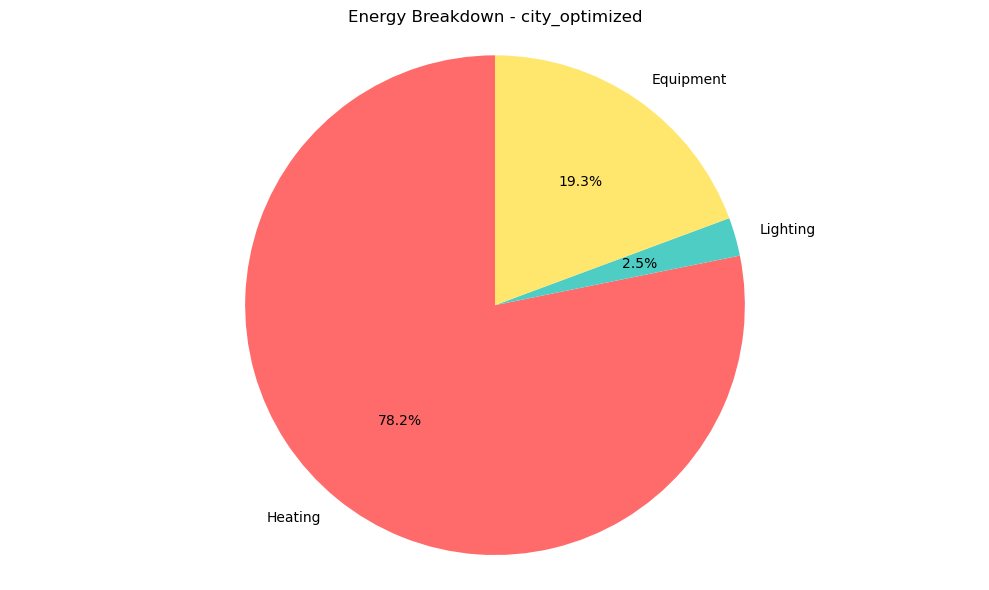


✓ Saved energy breakdown chart to: energy_breakdown.png

⏰ Hourly Timeseries Data Available:
  Total timesteps: 8760
  Available variables: 255
  Variables: ['BUILDING13_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING17_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING19_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING26_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING27_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING28_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING32_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING33_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING67_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J', 'BUILDING68_FLOOR1_ROOM1_Zone_Lights_Electricity_Energy_J']...

✓ Saved summary to: c:\Users\qiyu\EPSM\epsm\backend\notebooks\idf_output\energy_summary.csv
      Building  Total Energy (kWh/m²)  Heating (kWh/m²)  Cooling (kWh/m²)  Lighting (kWh/m²)  Equipment (kWh/m²)  Total Area (m²)  Annual Energy 

In [9]:
# Load and analyze the parsed results
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Load the results JSON
results_path = idf_output_path / "city_optimized_results.json"

if results_path.exists():
    with open(results_path, 'r') as f:
        results = json.load(f)
    
    print("📊 Loaded Results for:", results['building'])
    print("="*60)
    
    # 1. Access individual metrics
    total_energy = results.get('totalEnergyUse', 0)
    heating = results.get('heatingDemand', 0)
    cooling = results.get('coolingDemand', 0)
    lighting = results.get('lightingDemand', 0)
    equipment = results.get('equipmentDemand', 0)
    total_area = results.get('totalArea', 0)
    
    print(f"\n📈 Energy Performance:")
    print(f"  Total Energy: {total_energy:.2f} kWh/m²/year")
    print(f"  Heating: {heating:.2f} kWh/m²/year")
    print(f"  Cooling: {cooling:.2f} kWh/m²/year")
    print(f"  Lighting: {lighting:.2f} kWh/m²/year")
    print(f"  Equipment: {equipment:.2f} kWh/m²/year")
    print(f"  Total Floor Area: {total_area:,.0f} m²")
    
    # 2. Calculate total annual energy consumption
    total_annual_energy = total_energy * total_area
    print(f"\n💡 Total Annual Energy: {total_annual_energy:,.0f} kWh/year")
    
    # 3. Create energy breakdown pie chart
    energy_breakdown = {
        'Heating': heating,
        'Cooling': cooling,
        'Lighting': lighting,
        'Equipment': equipment
    }
    
    # Filter out zero values
    energy_breakdown = {k: v for k, v in energy_breakdown.items() if v > 0}
    
    if energy_breakdown:
        plt.figure(figsize=(10, 6))
        plt.pie(energy_breakdown.values(), 
                labels=energy_breakdown.keys(), 
                autopct='%1.1f%%',
                startangle=90,
                colors=['#ff6b6b', '#4ecdc4', '#ffe66d', '#95e1d3'])
        plt.title(f'Energy Breakdown - {results["building"]}')
        plt.axis('equal')
        plt.tight_layout()
        plt.savefig(idf_output_path / 'energy_breakdown.png', dpi=300)
        plt.show()
        print("\n✓ Saved energy breakdown chart to: energy_breakdown.png")
    
    # 4. Access hourly timeseries data (if available)
    if 'hourly_timeseries' in results:
        hourly = results['hourly_timeseries']
        print(f"\n⏰ Hourly Timeseries Data Available:")
        print(f"  Total timesteps: {hourly['rows']}")
        print(f"  Available variables: {len(hourly['series'])}")
        print(f"  Variables: {list(hourly['series'].keys())[:10]}...")
        
        # Plot a sample variable (e.g., heating demand)
        series = hourly['series']
        
        # Find heating-related variables
        heating_vars = [k for k in series.keys() if 'heating' in k.lower()]
        if heating_vars:
            var_name = heating_vars[0]
            values = series[var_name]
            
            # Plot first week (168 hours)
            plt.figure(figsize=(14, 6))
            plt.plot(values[:168])
            plt.title(f'First Week - {var_name}')
            plt.xlabel('Hour')
            plt.ylabel('Value')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(idf_output_path / 'hourly_profile.png', dpi=300)
            plt.show()
            print(f"\n✓ Saved hourly profile to: hourly_profile.png")
    
    # 5. Export summary to CSV for further analysis
    summary_data = {
        'Building': [results['building']],
        'Total Energy (kWh/m²)': [total_energy],
        'Heating (kWh/m²)': [heating],
        'Cooling (kWh/m²)': [cooling],
        'Lighting (kWh/m²)': [lighting],
        'Equipment (kWh/m²)': [equipment],
        'Total Area (m²)': [total_area],
        'Annual Energy (kWh)': [total_annual_energy]
    }
    
    import pandas as pd
    df = pd.DataFrame(summary_data)
    csv_path = idf_output_path / 'energy_summary.csv'
    df.to_csv(csv_path, index=False)
    print(f"\n✓ Saved summary to: {csv_path}")
    print(df.to_string(index=False))
    
else:
    print("❌ Results JSON not found. Run the parsing cell first.")